In [1]:
%load_ext autoreload
%autoreload 2
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from mne.time_frequency import tfr_morlet
from mne.time_frequency.tfr import morlet
from mne import combine_evoked
import seaborn as sns
from mne.decoding import Scaler
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.preprocessing import PowerTransformer

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
paradigm = P300(tmin=-1, tmax=2, resample=None, fmin=0.1, fmax=None)
dataset = BNCI2014009()

In [3]:
subject, session, run = 1, "session_0", "run_0"
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw

Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.


<RawArray | 18 x 50184 (196.0 s), ~6.9 MB, data loaded>

In [4]:
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Not setting metadata
576 matching events found
No baseline correction applied


Number of events,576
Events,NonTarget: 480Target: 96
Time range,-1.000 – 2.000 sec
Baseline,off


In [5]:
n_freqs = 16
freqs = np.linspace(1,32,n_freqs)
n_cycles = 0.8*freqs
sfreq=16

epochs_tfr = tfr_morlet(
    epochs, freqs, n_cycles, return_itc=False, average=False,
    output='complex', verbose=True, n_jobs=-1,
                        decim=int(epochs.info['sfreq']//sfreq))
#epochs_tfr.data = np.real(epochs_tfr.data)
epochs_tfr.apply_baseline((0,1.2), mode='zscore')
epochs_tfr.crop(0, 0.8)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 out of  16 | elapsed:    3.5s remaining:    2.7s
[Parallel(n_jobs=-1)]: Done  13 out of  16 | elapsed:    4.3s remaining:    1.0s
[Parallel(n_jobs=-1)]: Done  16 out of  16 | elapsed:    4.4s finished


Not setting metadata
Applying baseline correction (mode: zscore)


<EpochsTFR | time : [0.000000, 0.812500], freq : [1.000000, 32.000000], epochs : 576, channels : 16, ~31.5 MB>

No baseline correction applied


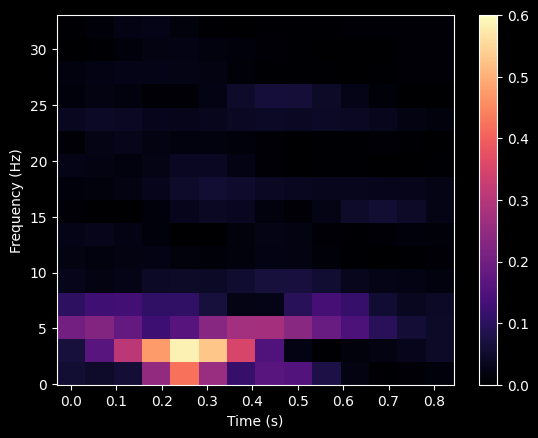

No baseline correction applied


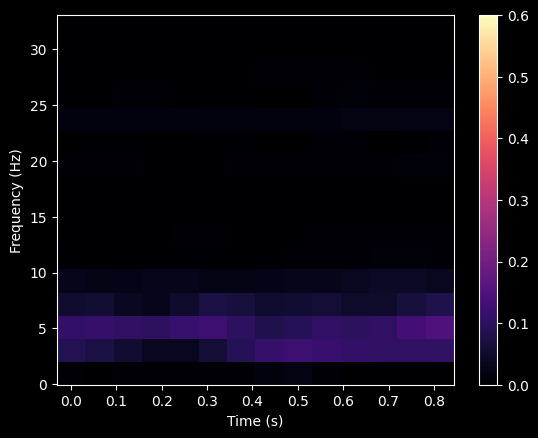

No baseline correction applied


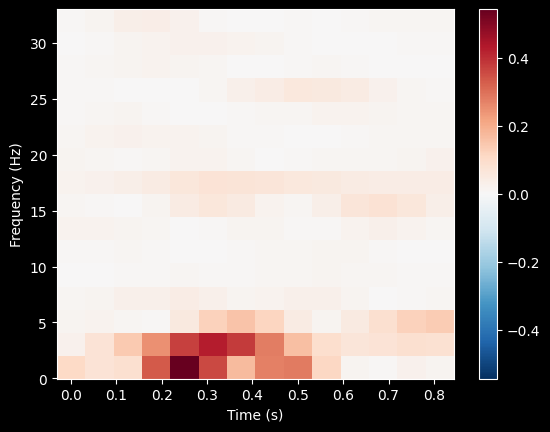

In [6]:
from mne import combine_evoked

plt.style.use('dark_background')


target = epochs_tfr['Target'].average()
non_target = epochs_tfr['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])

vmax = np.max(np.abs(target.data))
tfr_args=dict(picks=['Cz'], vmin=0, vmax=0.6, cmap='magma')

_ = target.plot(**tfr_args)
_ = non_target.plot(**tfr_args)
_ = contrast.plot(picks=['Cz'])

In [9]:
import tensorly as tl
tl.set_backend('numpy')

split = len(epochs)//2
X = tl.tensor(epochs_tfr.data, dtype=np.complex128)
X_train = X[:split]
X_test = X[split:]
y_train = labels[:split]
y_test = labels[split:]

In [21]:
import cupy
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from hoda.hoda import BTTDA
from sklearn.preprocessing import FunctionTransformer


hoda_lda = Pipeline([
        ('bttda', BTTDA(
            n_blocks=None,
            verbose=True,
            keep_train_info=True,
            hoda_params=dict(
                rank=None,
                max_iter=64,
                tol=1e-3,
                init ='mlsvd',
                verbose=True,
                shrinkage=(0,0,0),
                toeplitz=(2,),
                taper=False,
                solver='diff',
                keep_train_info=True,
            )
        )),
        ('complex',FeatureUnion([
            ('real', FunctionTransformer(np.real)),
            ('imag', FunctionTransformer(np.imag)),
        ])),
        ('lda', LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')),
        #('svm', SVC(kernel='rbf', C=1e-3)),

])

hoda_lda.fit(X_train,y_train)

Fitting block 1/None...
Initializing factors...
Fitting discriminative tucker model of rank [5, 5, 14] ...


  0%|          | 0/64 [00:00<?, ?it/s]


Fitting block 2/None...
Initializing factors...
Fitting discriminative tucker model of rank [4, 5, 13] ...


  0%|          | 0/64 [00:00<?, ?it/s]


Fitting block 3/None...
Initializing factors...
Fitting discriminative tucker model of rank [5, 6, 2] ...


  0%|          | 0/64 [00:00<?, ?it/s]

Pipeline(steps=[('bttda',
                 BTTDA(hoda_params={'init': 'mlsvd', 'keep_train_info': True,
                                    'max_iter': 64, 'rank': None,
                                    'shrinkage': (0, 0, 0), 'solver': 'diff',
                                    'taper': False, 'toeplitz': (2,),
                                    'tol': 0.001, 'verbose': True},
                       keep_train_info=True, verbose=True)),
                ('complex',
                 FeatureUnion(transformer_list=[('real',
                                                 FunctionTransformer(func=<function real at 0x7fd058050c20>)),
                                                ('imag',
                                                 FunctionTransformer(func=<function imag at 0x7fd058050e00>))])),
                ('lda',
                 LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))])

<AxesSubplot: xlabel='score', ylabel='Count'>

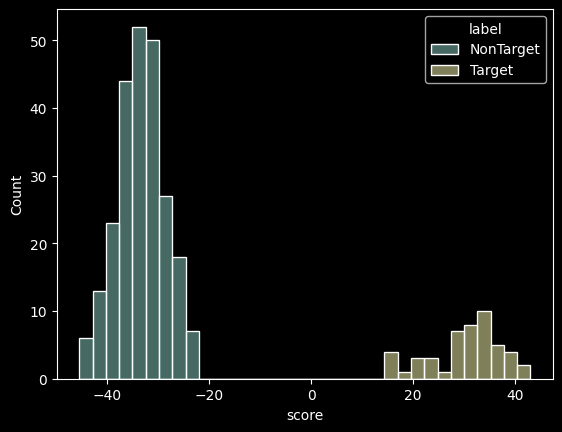

In [22]:
import pandas as pd

train_scores = cupy.asnumpy(hoda_lda.decision_function(X_train))
df = pd.DataFrame(dict(score=cupy.asnumpy(train_scores),label=y_train))
sns.histplot(data=df, x='score', hue='label')

In [23]:
roc_auc_score(y_train,train_scores)

1.0

<AxesSubplot: xlabel='score', ylabel='Count'>

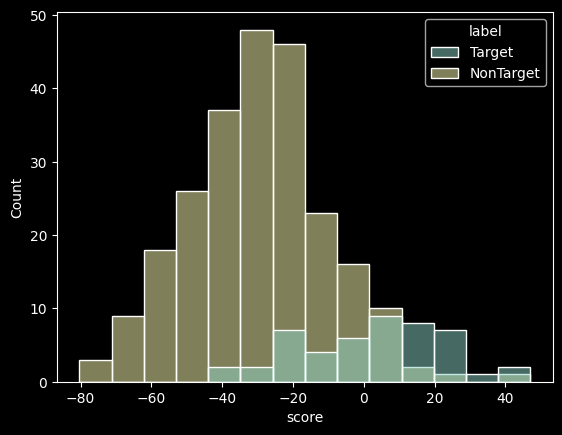

In [24]:
import pandas as pd

test_scores = cupy.asnumpy(hoda_lda.decision_function(X_test))
df = pd.DataFrame(dict(score=cupy.asnumpy(test_scores),label=y_test))
sns.histplot(data=df, x='score', hue='label')

In [25]:
roc_auc_score(y_test,test_scores)

0.8712673611111111